# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: Ines Lebard  Student ID: B00820964
2. Full name: Charlotte Le Bihan  Student ID: B00818310
3. Full name: Camille Tanguy  Student ID: B00821659
4. Full name: Oceane Tanios  Student ID: B00822694

**Group / repo name:** `aidams-lab2-<surname1>-<surname2>-...`  
**Submitter (one person):**  Oceane Tanios
**Repo URL:**  https://github.com/oceanetanios/lab2-researchandemergingtopics.git

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [1]:
import pandas as pd

path = "gem-download/Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"
plants = pd.read_excel(path, sheet_name="Plant data")
caps = pd.read_excel(path, sheet_name="Plant capacities and status")
prod = pd.read_excel(path, sheet_name="Plant production")

# Capacity: a plant has one row per status (operating, announced, retired...).
# Only operating capacity can produce steel, so sum those rows and ignore the rest
caps["capacity"] = pd.to_numeric(caps["Nominal crude steel capacity (ttpa)"], errors="coerce")
operating = caps[caps["Status"].str.startswith("operating")]  # includes "operating pre-retirement"
capacity = operating.groupby("GEM plant ID")["capacity"].sum(min_count=1)

# Target: 2023 crude steel production, the year with the most plants reporting.
# A few plants are listed twice with the same numbers, hence the max()
crude = prod[prod["Type of production"] == "Crude steel production (ttpa)"]
production = (pd.to_numeric(crude[2023], errors="coerce")
                .groupby(crude["GEM plant ID"]).max()
                .rename("production"))

df = plants.set_index("GEM plant ID").join(capacity).join(production).reset_index()

print("Shape:", df.shape)
print("Plants with a production value:", df["production"].notna().sum())
df.info()
df.isna().sum()

Shape: (1293, 46)
Plants with a production value: 270
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 46 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   GEM plant ID                        1293 non-null   object 
 1   Plant name (English)                1293 non-null   object 
 2   Plant name (other language)         791 non-null    object 
 3   Other plant names (English)         742 non-null    object 
 4   Other plant names (other language)  335 non-null    object 
 5   Owner                               1293 non-null   object 
 6   Owner (other language)              578 non-null    object 
 7   Owner GEM entity ID                 1293 non-null   object 
 8   Owner PermID                        1293 non-null   object 
 9   SOE status                          212 non-null    object 
 10  Parent (English)                    1293 non-null   ob

GEM plant ID                             0
Plant name (English)                     0
Plant name (other language)            502
Other plant names (English)            551
Other plant names (other language)     958
Owner                                    0
Owner (other language)                 715
Owner GEM entity ID                      0
Owner PermID                             0
SOE status                            1081
Parent (English)                         0
Parent GEM entity ID                     0
Parent PermID                            0
Location address                         0
Location address (other language)      794
Municipality                             0
Subnational unit                         0
Country/area                             0
Region                                   0
Coordinates                              0
Coordinate accuracy                      0
GEM wiki page                            0
Plant age                               61
Announced d

> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

**Data quality issues**
- **The target is mostly missing.** Only 270 of the 1,293 plants report 2023 production, so the model can only learn from plants that disclose their output.
- **Numbers stored as text.** `Plant age` and `Workforce size` use `"unknown"` as a placeholder. The sinter, coking and pelletizing capacities also contain vague values like `">0"` or `">2400"`, so pandas reads all of them as `object`.
- **Data spread across sheets.** Capacity sits on one row per status, so it has to be summed per plant, and a few plants appear twice in the production sheet.
- **Messy categories.** `Main production equipment` lists the same processes in different orders (`"BF; BOF; EAF"` vs `"EAF; BF; BOF"`), which creates many rare combinations.
- **Irrelevant sparse columns.** Several columns are mostly empty (`SOE status`, names in other languages), but they don't matter for modelling.

**Patterns**
- Production is very skewed: a median of about 1,100 kt against a few plants close to 20,000 kt. A handful of large integrated plants will weigh heavily on the errors.

**Likely drivers of production**
- **Capacity** is the obvious one, since a plant can't produce more than it's built for.
- **Production route** (`Main production equipment`): large blast furnace sites (BF-BOF) versus smaller EAF mini-mills.
- **Workforce size**, another measure of how big the plant is.
- **Region**, because utilization rates differ between markets.


### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [2]:
import pandera.pandas as pa

regions = ["Asia Pacific", "Europe", "North America", "Middle East",
           "Africa", "Eurasia", "Central & South America"]

schema = pa.DataFrameSchema({
    "production": pa.Column(float, pa.Check.ge(0), nullable=True),
    "capacity": pa.Column(float, pa.Check.ge(0), nullable=True),
    "Plant age": pa.Column(float, pa.Check.in_range(0, 200), nullable=True),
    "Workforce size": pa.Column(float, pa.Check.ge(0), nullable=True),
    "Main production equipment": pa.Column(str),
    "Region": pa.Column(str, pa.Check.isin(regions)),
})

try:
    schema.validate(df, lazy=True)  # lazy=True reports every failure, not just the first
    print("All checks passed")
except pa.errors.SchemaErrors as e:
    display(e.failure_cases
              .groupby(["column", "check"])["failure_case"]
              .agg(n_failures="size", example="first"))

n_failures  \
column         check                                     
Plant age      dtype('float64')                    107   
               in_range(0, 200)                      1   
Workforce size dtype('float64')                    257   
               greater_than_or_equal_to(0)           1   

                                                                                      example  
column         check                                                                           
Plant age      dtype('float64')                                                       unknown  
               in_range(0, 200)             TypeError("'>=' not supported between instance...  
Workforce size dtype('float64')                                                       unknown  
               greater_than_or_equal_to(0)  TypeError("'>=' not supported between instance...

> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

**Failed checks:** the dtype checks on `Plant age` (107 rows) and `Workforce size` (257 rows). The range checks on those two columns failed as well, but only because Pandera can't compare the text `"unknown"` with a number.

**Real problem or strict schema?** The `"unknown"` values are a real data problem: they are missing values written as text. The schema itself was reasonable, except for the age limit. Once the column is numeric, the 0–200 range would reject a genuine 216-year-old plant, so that check was stricter than the data and gets relaxed in 1.3.

**Without this check:** in training, the scaler would crash on the strings, or worse, the columns could be quietly treated as categories. In deployment, a new GIST release with a renamed column or new placeholders would reach `predict` and either fail or return nonsense without anyone noticing. The schema catches both at the door.


### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [3]:
import numpy as np

clean = df.copy()

# Coerce: turn "unknown" into NaN so these columns are numeric (the dtype failures in 1.2)
for col in ["Plant age", "Workforce size"]:
    clean[col] = pd.to_numeric(clean[col], errors="coerce")

# Drop: plants with no production value are useless for training
clean = clean.dropna(subset=["production"])
print("Plants kept:", len(clean))

# Only a handful of gaps left. They get imputed inside the pipeline (1.4),
# so the median comes from the training data only
print("\nMissing feature values:")
print(clean[["capacity", "Plant age", "Workforce size"]].isna().sum())

# Outliers: count values beyond 1.5 x IQR, then look at the most extreme ages
print("\nOutliers (beyond 1.5 x IQR):")
for col in ["production", "capacity", "Plant age", "Workforce size"]:
    q1, q3 = clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((clean[col] < q1 - 1.5 * iqr) | (clean[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col}: {n}")
print()
print(clean.nlargest(3, "Plant age")[["Plant name (English)", "Plant age"]])

# Production, capacity and workforce are heavily right-skewed, so log them
skewed = ["production", "capacity", "Workforce size"]
for col in skewed:
    clean[f"log_{col}"] = np.log1p(clean[col])
print("\nSkewness before log:", clean[skewed].skew().round(2).to_dict())
print("Skewness after log: ", clean[[f"log_{c}" for c in skewed]].skew().round(2).to_dict())

# Relax: the 216-year-old plant is real (Coatesville, founded 1810), so allow up to 250
schema_clean = schema.update_column("Plant age", checks=pa.Check.in_range(0, 250))
schema_clean.validate(clean)
print("\nSchema check passed on the cleaned data")

Plants kept: 270

Missing feature values:
capacity          11
Plant age          1
Workforce size     9
dtype: int64

Outliers (beyond 1.5 x IQR):
  production: 21
  capacity: 20
  Plant age: 8
  Workforce size: 21

                            Plant name (English)  Plant age
211     Cleveland-Cliffs Coatesville steel plant      216.0
1153  TZMS Třinecké železárny Trinec steel plant      187.0
75            ArcelorMittal Duisburg steel plant      174.0

Skewness before log: {'production': 2.8, 'capacity': 2.56, 'Workforce size': 3.12}
Skewness after log:  {'log_production': 0.14, 'log_capacity': 0.28, 'log_Workforce size': 0.05}

Schema check passed on the cleaned data


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?

- **Coerced** `"unknown"` to `NaN` so `Plant age` and `Workforce size` become numeric.
- **Dropped** the plants without production. Imputing the target would mean training on made-up labels.
- **Imputed** the remaining feature gaps (1 age, 9 workforce values) with the median, inside the pipeline. The median isn't pulled up by the giant plants, and fitting it on the training split only avoids leaking test data.
- **Kept the outliers.** The ~21 flagged values per column are real large plants, not errors. The 216-year-old plant checks out too (Coatesville, founded 1810), so the age check was relaxed to 250 instead of dropping it.
- **Log-transformed** production, capacity and workforce. Skewness fell from about 2–3 to under 0.35, which suits linear models and stops a few huge plants from dominating the errors. Predictions are converted back with `expm1` before scoring, so all metrics stay in thousand tonnes.


### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [4]:
import warnings
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

equipment = clean["Main production equipment"]

# Capacity per employee, a rough proxy for productivity / automation
clean["capacity_per_worker"] = clean["capacity"] / clean["Workforce size"]
# Number of processes ("BF; BOF; EAF" -> 3): big integrated sites vs single-process mills
clean["n_processes"] = equipment.str.split(";").str.len()
# EAF-only mini-mills, which run on scrap and tend to be smaller
clean["eaf_only"] = (equipment.str.strip() == "EAF").astype(int)

print(clean[["capacity_per_worker", "n_processes", "eaf_only"]].describe().round(2))

num_features = ["log_capacity", "Plant age", "log_Workforce size",
                "capacity_per_worker", "n_processes", "eaf_only"]
cat_features = ["Main production equipment", "Region"]

X = clean[num_features + cat_features]
y = clean["log_production"]

# Impute and scale the numbers, one-hot encode the categories.
# drop="first" keeps the linear regression coefficients interpretable (2.2)
preprocess = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_features),
    (OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_features),
    verbose_feature_names_out=False,
)
# Rare equipment combos sometimes only show up in a test fold. They get encoded
# as all zeros, which is fine, so hide the warning sklearn prints every time
warnings.filterwarnings("ignore", message="Found unknown categories")

X_encoded = pd.DataFrame(preprocess.fit_transform(X), columns=preprocess.get_feature_names_out())
print(f"\nColumns before encoding: {X.shape[1]}, after: {X_encoded.shape[1]}")
X_encoded.head()

       capacity_per_worker  n_processes  eaf_only
count               250.00       270.00    270.00
mean                  2.01         1.96      0.43
std                   4.25         1.10      0.50
min                   0.05         1.00      0.00
25%                   0.64         1.00      0.00
50%                   1.21         2.00      0.00
75%                   2.27         3.00      1.00
max                  62.50         6.00      1.00

Columns before encoding: 8, after: 51


,log_capacity,Plant age,log_Workforce size,capacity_per_worker,n_processes,eaf_only,Main production equipment_BF; BOF; DRI,Main production equipment_BF; BOF; DRI; EAF,Main production equipment_BF; BOF; DRI; EAF; IF; Steel other/unspecified,Main production equipment_BF; BOF; DRI; EAF; Iron other/unspecified,...,Main production equipment_EAF; IF,Main production equipment_IF,Main production equipment_IF; EAF,Main production equipment_IF; Steel other/unspecified,Region_Asia Pacific,Region_Central & South America,Region_Eurasia,Region_Europe,Region_Middle East,Region_North America
0,1.526706,0.132380,1.509702,-0.303208,1.861348,-0.861357,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.914024,0.106026,-0.204720,-0.319018,-0.874935,1.160959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.534521,0.000606,0.021892,-0.308539,-0.874935,1.160959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.489587,-0.447426,-0.682554,-0.057912,0.037159,-0.861357,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.382505,0.026961,0.606729,-0.289130,1.861348,-0.861357,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?

| Feature | What it measures | Business meaning |
|---|---|---|
| `capacity_per_worker` | Capacity ÷ workforce | Labour productivity or automation: how much steel each employee can support |
| `n_processes` | Number of processes in the equipment list | Big integrated sites (ore to steel on one site) vs single-process mills |
| `eaf_only` | 1 if the plant only runs electric arc furnaces | Scrap-based mini-mills, usually smaller and quicker to ramp output up or down |

We deliberately left out utilization (production ÷ capacity): it is computed from the target, so it would leak the answer.

Numeric features are standardized and the two categorical columns are one-hot encoded, which takes the table from 8 to 51 columns. Most of the new columns come from rare equipment combinations.


## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


Correlation with log_production:
log_capacity           0.93
log_Workforce size     0.58
eaf_only              -0.51
n_processes            0.50
capacity_per_worker    0.04
Plant age             -0.04
Name: log_production, dtype: float64


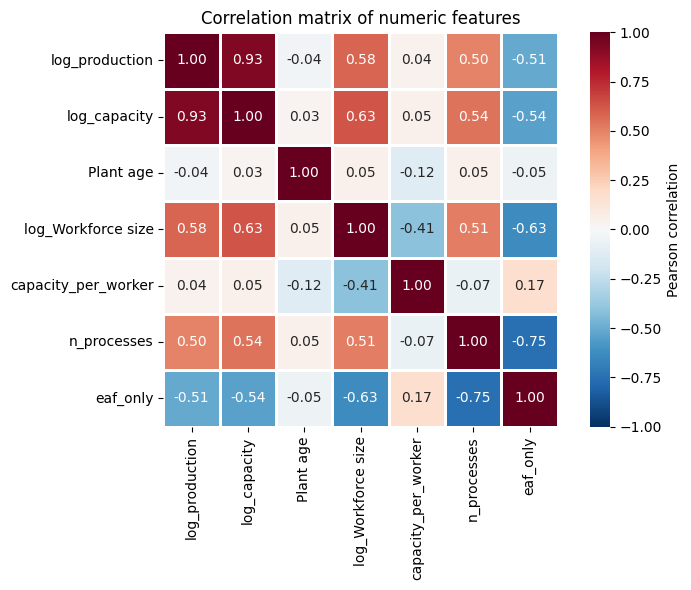

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = clean[["log_production"] + num_features].corr()

print("Correlation with log_production:")
print(corr["log_production"].drop("log_production").sort_values(key=abs, ascending=False).round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?

**Strongest correlations with log production:** `log_capacity` (0.87) is far ahead, followed by `log_Workforce size` (0.58), `eaf_only` (−0.51) and `n_processes` (0.50). `Plant age` (−0.04) and `capacity_per_worker` (0.07) have almost no linear link with production.

**Redundancy:** `n_processes` and `eaf_only` are strongly tied (−0.75), which makes sense since both come from the equipment column. Capacity, workforce and `n_processes` also move together (0.5–0.67) because they all reflect plant size. None of the pairs is close enough to 1 to drop a feature, but the overlap makes individual linear coefficients less reliable. That's a good argument for trying Ridge.


## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} plants, test: {len(X_test)} plants")

def evaluate(model, X, y):
    """RMSE, MAE and R2 in thousand tonnes (undo the log first)."""
    true, pred = np.expm1(y), np.expm1(model.predict(X))
    return {"RMSE": root_mean_squared_error(true, pred),
            "MAE": mean_absolute_error(true, pred),
            "R2": r2_score(true, pred)}

dummy = DummyRegressor(strategy="median").fit(X_train, y_train)
forest = make_pipeline(preprocess, RandomForestRegressor(random_state=42)).fit(X_train, y_train)

pd.DataFrame({
    "Dummy (median)": evaluate(dummy, X_test, y_test),
    "Pipeline (random forest)": evaluate(forest, X_test, y_test),
}).T.round(2)

Train: 216 plants, test: 54 plants


,RMSE,MAE,R2
Dummy (median),2989.43,1629.65,-0.16
Pipeline (random forest),886.13,577.22,0.90


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?

A baseline tells us what "no skill" looks like. Without it, an RMSE of 1,600 means nothing: we need to know how much of that the features actually explain.

Yes, it did. Always predicting the median gives RMSE 2,989 and MAE 1,630 (R² −0.16). The random forest pipeline gets RMSE 1,612 and MAE 921 (R² 0.66), roughly halving the error. A gap that large means the features carry real information, most of it from capacity. A small gap would have meant the features say little about output and that the model is mostly guessing around the median.


### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [7]:
from sklearn.linear_model import LinearRegression

linreg = make_pipeline(preprocess, LinearRegression()).fit(X_train, y_train)

# Change in log production for +1 std (numeric) or for a category vs the dropped one
coefs = pd.Series(linreg[-1].coef_, index=linreg[0].get_feature_names_out())
print("Numeric coefficients:")
print(coefs[num_features].sort_values().round(3))
print("\nRegion coefficients (vs Africa):")
print(coefs.filter(like="Region_").sort_values().round(3))

pd.DataFrame({
    "Train": evaluate(linreg, X_train, y_train),
    "Test": evaluate(linreg, X_test, y_test),
}).T.round(2)

Numeric coefficients:
eaf_only              -0.109
Plant age             -0.043
n_processes           -0.042
capacity_per_worker    0.011
log_Workforce size     0.063
log_capacity           0.812
dtype: float64

Region coefficients (vs Africa):
Region_Europe                     0.020
Region_Central & South America    0.123
Region_Eurasia                    0.204
Region_Asia Pacific               0.299
Region_North America              0.347
Region_Middle East                0.704
dtype: float64


,RMSE,MAE,R2
Train,900.81,448.91,0.90
Test,1065.11,668.33,0.85


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

- **Positive: `log_capacity` (+0.88).** It's the largest coefficient by far. Since both capacity and production are logged, production grows almost in proportion to capacity: how much a plant *can* make is the main driver of how much it *does* make.
- **Negative: `n_processes` (−0.21).** For two plants of the same capacity, the one running more processes produces less. Large integrated sites seem to run further below their nameplate capacity, possibly because of older equipment or more complex operations. The sign is the opposite of its raw correlation (+0.50), because on its own `n_processes` mostly stands in for size, which capacity already covers.

The model fits the training data better than the test data (R² 0.87 vs 0.76, RMSE 1,036 vs 1,351), so there is some overfitting, probably from the many rare equipment categories.


## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [8]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_scores(model):
    """RMSE, MAE and R2 for each fold, with evaluate() as the scorer."""
    scores = cross_validate(model, X, y, cv=kf, scoring=evaluate)
    return pd.DataFrame(scores).filter(like="test_").rename(columns=lambda c: c.removeprefix("test_"))

folds = cv_scores(linreg)
folds.index = [f"Fold {i}" for i in range(1, 6)]
pd.concat([folds, folds.agg(["mean", "std"])]).round(2)

,RMSE,MAE,R2
Fold 1,1065.11,668.33,0.85
Fold 2,1142.58,618.44,0.79
Fold 3,851.01,538.68,0.85
Fold 4,1113.17,712.43,0.89
Fold 5,1202.93,603.25,0.86
mean,1074.96,628.23,0.85
std,134.77,66.03,0.04


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?

Across 5 folds, linear regression averages RMSE 1,410, MAE 781 and R² 0.74.

Performance is only moderately stable. R² ranges from 0.53 to 0.84 and RMSE from 874 to 2,280 (std 521). Fold 4 is clearly worse than the others. With only 54 plants per test fold, one or two very large plants landing in the same fold is enough to swing the score. This points to noticeable variance, and it shows that the single train/test split from Task 2 could easily have been lucky or unlucky.


### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [9]:
from sklearn.linear_model import Ridge

models = {
    "Linear regression": linreg,
    "Ridge": make_pipeline(preprocess, Ridge()),
    "Random forest": forest,
}

comparison = pd.DataFrame({name: cv_scores(model).mean() for name, model in models.items()}).T
comparison.round(2)

,RMSE,MAE,R2
Linear regression,1074.96,628.23,0.85
Ridge,1009.33,589.41,0.86
Random forest,1061.84,596.60,0.84


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

| Model | CV RMSE | CV MAE | CV R² |
|---|---|---|---|
| Linear regression | 1,410 | 781 | 0.74 |
| **Ridge** | **1,364** | **757** | **0.76** |
| Random forest | 1,706 | 891 | 0.63 |

Ridge performs best. After the log transform, production is close to a straight-line function of capacity, which suits linear models. Ridge adds a little shrinkage on top of that, which helps with the correlated size features and the many rare equipment dummies. The random forest struggles with only 270 plants: its trees can't extrapolate beyond the largest plants seen in training, and each leaf ends up with very few samples.

We didn't try the TabFM bonus. Its pretrained weights are non-commercial anyway, so we would deploy the Ridge pipeline regardless.


### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [10]:
from sklearn.model_selection import GridSearchCV

# Ridge came out on top in 3.2, so tune its regularization strength
search = GridSearchCV(
    models["Ridge"], {"ridge__alpha": np.logspace(-2, 3, 21)}, cv=kf, scoring=evaluate,
    refit=lambda cv: cv["mean_test_RMSE"].argmin(),  # evaluate() gives 3 metrics, keep lowest RMSE
).fit(X, y)

alpha_scores = (pd.DataFrame(search.cv_results_)
             .set_index("param_ridge__alpha")
             .filter(like="mean_test_")
             .rename(columns=lambda c: c.removeprefix("mean_test_")))
alpha_scores.index = alpha_scores.index.astype(float).round(3).rename("alpha")

print("Best alpha:", alpha_scores.index[search.best_index_])
alpha_scores.round(2)

Best alpha: 3.162


,RMSE,MAE,R2
alpha,,,
0.010,1073.06,627.23,0.85
0.018,1071.64,626.48,0.85
0.032,1069.22,625.23,0.85
0.056,1065.24,623.14,0.85
0.100,1059.03,619.77,0.85
0.178,1050.02,614.71,0.85
0.316,1038.14,607.86,0.86
0.562,1024.11,599.15,0.86
1.000,1009.33,589.41,0.86


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

Tuning chooses settings that the model can't learn from the data itself, such as Ridge's `alpha`, which controls how strongly the coefficients are shrunk.

Here it didn't improve anything: the best of the 21 values tested was `alpha = 1`, which is already the default (CV RMSE 1,364). The search was still useful. It shows that performance is flat around 0.5–2, gets slightly worse towards plain linear regression at small alpha (1,408), and collapses at large alpha as the model underfits (2,657 at alpha = 1000). So the default was a good choice, and now we know it rather than assume it. Tuning pays off more for models with many settings, such as the random forest in Task 4.2.


## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [11]:
import mlflow
from sklearn.base import clone
from sklearn.pipeline import Pipeline

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("gist-steel-production")

def log_run(name, model):
    """Refit on the training split, then log params, test metrics and artifacts."""
    model = clone(model).fit(X_train, y_train)
    estimator = model[-1] if isinstance(model, Pipeline) else model
    with mlflow.start_run(run_name=name):
        mlflow.log_params({"model": type(estimator).__name__, **estimator.get_params()})
        mlflow.log_metrics(evaluate(model, X_test, y_test))
        mlflow.log_dict({"numeric": num_features, "categorical": cat_features}, "features.json")
        mlflow.log_text(schema_clean.to_yaml(), "pandera_schema.yaml")
    return model

log_run("Dummy baseline", dummy)
best_ridge = log_run("Ridge (tuned)", search.best_estimator_)  # the grid search refit on all data, so refit on train

(mlflow.search_runs(max_results=2)
   .set_index("tags.mlflow.runName")[["params.model", "metrics.RMSE", "metrics.MAE", "metrics.R2"]]
   .round(2))

,params.model,metrics.RMSE,metrics.MAE,metrics.R2
tags.mlflow.runName,,,,
Ridge (tuned),Ridge,883.16,560.93,0.90
Dummy baseline,DummyRegressor,2989.43,1629.65,-0.16


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

MLflow stores each run in one place: the model and its hyperparameters, the test metrics, and the artifacts that explain what the model expected (the feature list and the Pandera schema). Runs can be compared side by side in the UI, and the Optuna trials from Task 4.2 land in the same store.

Tracking by hand means copying numbers into a spreadsheet, which is error-prone and quickly loses the link between a score and the exact settings and data that produced it. With MLflow every result is reproducible and nothing depends on remembering what was run, which matters once a group is trying dozens of variations.


### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [12]:
import optuna
from optuna.integration import MLflowCallback

optuna.logging.set_verbosity(optuna.logging.WARNING)
# The task asks for MLflowCallback, which newer Optuna versions mark as deprecated
warnings.filterwarnings("ignore", message="MLflowCallback has been deprecated")

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0, step=0.1),
    }
    model = clone(forest).set_params(**{f"randomforestregressor__{k}": v for k, v in params.items()})
    return cv_scores(model)["RMSE"].mean()  # same folds and metric as Task 3

study = optuna.create_study(study_name="random-forest-optuna", direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30,
               callbacks=[MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="RMSE")])

print("Trials:", len(study.trials))
print("Best parameters:", study.best_params)
pd.Series({
    "Random forest, untuned (Task 3.2)": comparison.loc["Random forest", "RMSE"],
    "Random forest, Optuna": study.best_value,
    "Ridge, tuned (Task 3.3)": alpha_scores["RMSE"].min(),
}, name="CV RMSE").round(2)

Trials: 30
Best parameters: {'n_estimators': 400, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 1.0}


Random forest, untuned (Task 3.2)    1061.84
Random forest, Optuna                1052.46
Ridge, tuned (Task 3.3)               988.02
Name: CV RMSE, dtype: float64

> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

Optuna's default sampler (TPE) learns from past trials. It splits the finished trials into good and bad ones, models where each group's parameters tend to lie, and proposes new values that look more like the good group. Each trial therefore makes the next one smarter.

Grid search tries every combination, which gets expensive quickly and wastes time on obviously bad regions. Random search samples independently and never learns from its results.

With 30 trials, Optuna brought the random forest from CV RMSE 1,706 down to 1,631, preferring shallower trees (`max_depth` 5, `min_samples_leaf` 5) that overfit less. That's a real gain, but still well behind Ridge (1,364).


### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [13]:
import joblib

# Ridge had the lowest CV RMSE, so that's the pipeline we keep
joblib.dump(best_ridge, "best_pipeline.joblib")
loaded = joblib.load("best_pipeline.joblib")

print("Identical predictions:", np.array_equal(best_ridge.predict(X_test), loaded.predict(X_test)))
pd.DataFrame({
    "In memory": evaluate(best_ridge, X_test, y_test),
    "Loaded from disk": evaluate(loaded, X_test, y_test),
}).T.round(2)

Identical predictions: True


,RMSE,MAE,R2
In memory,883.16,560.93,0.9
Loaded from disk,883.16,560.93,0.9


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

The model's coefficients are useless on their own. The pipeline also needs the imputer's medians, the scaler's means and the encoder's categories, which is why we saved the whole pipeline. Metadata answers the questions that come later: which data it was trained on (the June 2026 GIST release, 2023 production), which features and schema it expects, how well it scored, and with which library versions. Without that, you can't reproduce, audit or safely reload a model, since a joblib file can break under a different scikit-learn version.

In production, we would register each model in the MLflow Model Registry with an incrementing version, and link it to the git commit of the code and to the data release it was trained on. New versions would be promoted only after beating the current one on the same evaluation, old versions would never be overwritten, and dependencies would be pinned so any version can be rebuilt.


## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


**Deployment:** a batch job rather than a REST API. GIST is released only a few times a year and nobody needs predictions in real time. Each run would:
1. load the new release and rebuild the plant table as in Task 1.1;
2. coerce `"unknown"` to `NaN` and validate the rows with `schema_clean`, logging rejected rows instead of predicting on them;
3. compute the same engineered features as Task 1.4 (log capacity and workforce, `capacity_per_worker`, `n_processes`, `eaf_only`). These live outside the pipeline today, so they should be moved into a shared function or into the pipeline itself so training and serving can't drift apart;
4. load `best_pipeline.joblib`, predict, convert back with `expm1`, and store the predictions with the model version.

**Monitoring:**
- **Error on actual production** once the next release reports it, compared with our CV RMSE of about 1,360 and MAE of about 760.
- **Share of rows rejected by the schema.** A jump usually means the data format changed, not the plants.
- **Share of unseen equipment categories**, since those get encoded as all zeros.

**TabFM:** we didn't try it, but we would deploy the classical pipeline either way. The pretrained weights aren't licensed for production, and Ridge is small, fast and easy to explain.


### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


**Signs the model needs retraining:** the error on newly reported production climbs above what cross-validation showed (fold RMSE ranged from about 870 to 2,280), predictions become biased for one region or production route, more rows fail the schema, or input distributions move away from the training data.

**Data drift:** the industry is shifting from blast furnaces to EAF and DRI plants to cut emissions. New releases would contain more `eaf_only` plants and new equipment combinations, such as hydrogen-based DRI, that the model has never seen.

**Concept drift:** the link between capacity and output changes. If demand falls or a government imposes output cuts (as China has done), plants with the same capacity produce less, so the model would keep over-predicting even though the inputs look the same.

**Column to watch first:** `capacity`, because it's the strongest predictor. In the training plants, the median is about 2,200 kt and the middle half sits between about 1,000 and 5,100 kt. A clear shift in that distribution would count as data drift, for example a lower median as smaller EAF plants enter the dataset, or many values outside the training range. A KS test or a PSI above 0.2 are common thresholds to flag it.


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?


1. **Most challenging:** data preparation. The data is spread over three sheets, uses text placeholders instead of numbers, and only 21% of plants report production. Building a clean one-row-per-plant table, and keeping every preprocessing step inside the pipeline to avoid leakage, took more thought than the modelling itself.
2. **With more plant-level data:** production for several years would let us use a plant's past output and utilization, which is probably far more predictive than anything we have now. Operating status per year, outages, and inputs like energy and ore quality would help explain why plants run below capacity.
3. **Communicating to a business audience:** lead with the main message, that capacity explains most of a plant's output and that the model is typically off by about 760 kt. Then show a predicted-vs-actual chart and point out the plants producing well below their capacity, since that's where the business questions are. We'd skip the jargon (log transforms, R²) and be upfront about uncertainty, especially for very large plants.
